# LaSRC Container Validation Notebook

## Purpose

This notebook compares **old** and **new** LaSRC container outputs from S3 and supports two output stages:

- **Immediate LaSRC outputs** such as `..._sr_band4.img`
- **Final HLS outputs** such as `...B04.tif`

The notebook keeps the same section flow as [`HLS_SR_acceptance_test.ipynb`](/Users/vo25-mbp/hls-validation/hls_validation_framework/notebooks/HLS_SR_acceptance_test.ipynb) for steps **1 through 6**, removes the statistical-test section, and replaces it with an atmospheric-correction acceptance workflow based on the **MD** thresholds from the reference table.

The main pass/fail rule used here is:

> A band passes when the absolute mean reflectance difference between the pre and post container outputs is less than or equal to the configured atmospheric-correction MD threshold for that band.


---
## 1. Configuration
Edit the variables in this cell only. Do not hardcode paths elsewhere in the notebook.


In [27]:
# ── Input roots: S3 prefixes or local directories ────────────────────────
# These can point either to:
# 1. an S3 prefix written as 'bucket/prefix/...'
# 2. a local directory that directly contains HLS product folders
#
# Example S3 final-output prefix:
#   'my-bucket/lasrc-validation/output_pre/'
# Example local experiment folders:
#   '/Users/vo25-mbp/Documents/NASA-IMPACT/HLS/LaSRC_container_testing_3.5.2_tmp/output/GFS_6x6_0.0000275:-0.20 '
#   '/Users/vo25-mbp/Documents/NASA-IMPACT/HLS/LaSRC_container_testing_3.5.2_tmp/output/GFS_6x6_0.00000275:-0.20_Jun26'
folder_pre = 's3://hls-science-container-testing-018923174646-us-west-2-an/lasrc-port/c/'
folder_post = 's3://hls-science-container-testing-018923174646-us-west-2-an/lasrc-port/rust/'

# ── Labels used in plots and summaries ────────────────────────────────────
PRE_LABEL = 'LaSRC C'
POST_LABEL = 'LaSRC Rust'

# ── AWS authentication / region ──────────────────────────────────────────
# Set AWS_PROFILE to a named profile if you use `aws sso login` or shared
# credentials/config files. Leave as None to use boto3's default chain.
AWS_PROFILE = None
AWS_REGION = 'us-west-2'
# For S3-backed reads, 'cache' is usually faster than direct /vsis3/ reads
# because each raster is read end-to-end with ReadAsArray().
# Use 'auto' to try direct S3 first, or 'direct' to require remote reads only.
S3_READ_MODE = 'cache'

# ── Data source selection ────────────────────────────────────────────────
# 'local' -> read from LOCAL_PRE_ROOT / LOCAL_POST_ROOT only
# 's3'    -> require folder_pre / folder_post to be S3 prefixes
# 'auto'  -> prefer LOCAL_* roots when both exist, otherwise auto-detect
#            whether folder_pre / folder_post are local directories or S3
DATA_SOURCE_MODE = 's3'
LOCAL_PRE_ROOT = None
LOCAL_POST_ROOT = None

#   '/Users/vo25-mbp/Documents/NASA-IMPACT/HLS/LaSRC_container_testing_3.5.2_tmp/output/GFS_6x6_0.00000275:-0.20_Jun26'

# ── Comparison mode ────────────────────────────────────────────────────────
# 'auto'      -> compare both final .tif and immediate .img files when found
# 'final'     -> compare only final HLS .tif files
# 'immediate' -> compare only immediate LaSRC .img files
COMPARISON_STAGE = 'immediate'

# ── Optional filters ───────────────────────────────────────────────────────
# Leave empty to compare every matched granule
GRANULE_FILTERS = []
# Keep this notebook small and visual. Use the CLI for large runs.
MAX_GRANULES = 10
# Leave empty to include every detected band
BANDS_TO_INCLUDE = []
# Exclude bands from comparison even if they are discovered
BANDS_TO_EXCLUDE = ['B8A']

# ── Visualization controls ────────────────────────────────────────────────
# Set to None to auto-select the first available granule after filtering
PANEL_GRANULE = None
# 'auto' prefers final outputs when available, otherwise immediate
PANEL_STAGE = 'auto'
SAVE_PANEL_IMAGES = True
SHOW_INLINE_PANELS = True
# Pixels whose absolute reflectance difference is <= this value are treated as unchanged
PIXEL_DIFF_EPS = 0.0
# Leave empty to show every detected band in the per-granule panel.
PANEL_BANDS = []

# ── C-versus-Rust equivalence threshold ────────────────────────────────
# Use one threshold for every discovered band: 5 HLS DN equals 0.0005
# reflectance under the final HLS scale factor of 0.0001.
THRESHOLD_REFL = 0.0005
THRESHOLD_SOURCE = '5 HLS DN equivalence threshold'

BAND_LABELS = {
    'B01': 'Ultrablue',
    'B02': 'Blue',
    'B03': 'Green',
    'B04': 'Red',
    'B05': 'Red Edge 1',
    'B06': 'Red Edge 2',
    'B07': 'Red Edge 3',
    'B08': 'NIR Broad',
    'B8A': 'NIR Narrow',
    'B09': 'Water Vapor',
    'B10': 'Cirrus',
    'B11': 'SWIR1',
    'B12': 'SWIR2',
}

BAND_ORDER = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12']

# ── Scaling / fill conventions ────────────────────────────────────────────
HLS_SCALE_FACTOR = 0.0001
FINAL_FILL_VALUE = -9999
IMMEDIATE_FILL_VALUE = 0
# Test-only override for Rust outputs that forgot to encode nodata=0 in the raster metadata.
# Set one of these to True only for temporary comparison experiments.
PRE_ZERO_IS_NODATA = False
POST_ZERO_IS_NODATA = False

# ── Output directories ────────────────────────────────────────────────────
import os
from pathlib import Path

BASE_DIR = Path(os.path.abspath(os.path.join('', '..')))
ENV_FILE = BASE_DIR / '.env'
REPORT_DIR = BASE_DIR / 'reports'
OUTPUTS_DIR = BASE_DIR / 'outputs' / 'lasrc_validation'
CACHE_DIR = OUTPUTS_DIR / '_cache'

REPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Report dir : {REPORT_DIR}')
print(f'Output dir : {OUTPUTS_DIR}')
print(f'Cache dir  : {CACHE_DIR}')
print(f'S3 read mode   : {S3_READ_MODE}')
print(f'Data source mode: {DATA_SOURCE_MODE}')
print(f'Local pre root : {LOCAL_PRE_ROOT}')
print(f'Local post root: {LOCAL_POST_ROOT}')
print(f'folder_pre     : {folder_pre}')
print(f'folder_post    : {folder_post}')


Report dir : /Users/vo25-mbp/hls-application-lasrc-validation/reports
Output dir : /Users/vo25-mbp/hls-application-lasrc-validation/outputs/lasrc_validation
Cache dir  : /Users/vo25-mbp/hls-application-lasrc-validation/outputs/lasrc_validation/_cache
S3 read mode   : cache
Data source mode: s3
Local pre root : None
Local post root: None
folder_pre     : s3://hls-science-container-testing-018923174646-us-west-2-an/lasrc-port/c/
folder_post    : s3://hls-science-container-testing-018923174646-us-west-2-an/lasrc-port/rust/


---
## 2. Setup
Imports, module loading, and S3 client initialisation.


In [7]:
import os
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

try:
    import boto3
    from botocore.exceptions import ClientError, NoCredentialsError
except ImportError as exc:
    raise ImportError('boto3 is required for S3 access in this notebook.') from exc

try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import matplotlib.ticker as mticker
except ImportError as exc:
    raise ImportError('matplotlib is required for notebook visualizations.') from exc

try:
    from osgeo import gdal
    gdal.UseExceptions()
except ImportError as exc:
    raise ImportError('GDAL (osgeo.gdal) is required to open .img and .tif rasters.') from exc

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = False

def load_env_file(env_path):
    env_path = Path(env_path)
    loaded = []
    if not env_path.exists():
        return loaded
    for raw_line in env_path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('export '):
            line = line[len('export '):].strip()
        if '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip("\"'")
        os.environ[key] = value
        loaded.append(key)
    return loaded

loaded_env_keys = load_env_file(ENV_FILE)
if loaded_env_keys:
    aws_keys = [k for k in loaded_env_keys if k.startswith('AWS_')]
    print(f'✅ Loaded environment file: {ENV_FILE}')
    if aws_keys:
        print('   AWS keys found in .env:', ', '.join(sorted(aws_keys)))
else:
    print(f'ℹ️  No .env file loaded from {ENV_FILE}')

try:
    if AWS_PROFILE is None and os.environ.get('AWS_PROFILE'):
        AWS_PROFILE = os.environ['AWS_PROFILE']
    session_kwargs = {'region_name': AWS_REGION}
    if AWS_PROFILE:
        session_kwargs['profile_name'] = AWS_PROFILE
    session = boto3.Session(**session_kwargs)
    creds = session.get_credentials()
    if creds is None:
        raise NoCredentialsError()
    frozen = creds.get_frozen_credentials()
    os.environ['AWS_DEFAULT_REGION'] = AWS_REGION
    os.environ['AWS_ACCESS_KEY_ID'] = frozen.access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = frozen.secret_key
    if frozen.token:
        os.environ['AWS_SESSION_TOKEN'] = frozen.token
    if AWS_PROFILE:
        os.environ['AWS_PROFILE'] = AWS_PROFILE

    gdal.SetConfigOption('AWS_REGION', AWS_REGION)
    gdal.SetConfigOption('AWS_ACCESS_KEY_ID', frozen.access_key)
    gdal.SetConfigOption('AWS_SECRET_ACCESS_KEY', frozen.secret_key)
    if frozen.token:
        gdal.SetConfigOption('AWS_SESSION_TOKEN', frozen.token)

    s3 = session.client('s3', region_name=AWS_REGION)
    print(f'✅ AWS credentials loaded (key: {frozen.access_key[:8]}...)')
    if AWS_PROFILE:
        print(f'   Using AWS profile: {AWS_PROFILE}')
except NoCredentialsError as exc:
    print('❌ No AWS credentials were found by boto3.')
    print(f'   Checked .env file: {ENV_FILE}')
    print('Try one of these before running the notebook again:')
    print('  1. If you use AWS CLI profiles or AWS SSO:')
    print('     - set AWS_PROFILE in the configuration cell')
    print('     - run `aws sso login --profile <your-profile>` in a terminal if needed')
    print('  2. If you use environment variables:')
    print('     export AWS_ACCESS_KEY_ID=...')
    print('     export AWS_SECRET_ACCESS_KEY=...')
    print('     export AWS_SESSION_TOKEN=...   # if using temporary credentials')
    print('  3. If you already configured the default AWS CLI profile, leave AWS_PROFILE=None')
    raise


✅ Loaded environment file: /Users/vo25-mbp/hls-application-lasrc-validation/.env
   AWS keys found in .env: AWS_PROFILE
✅ AWS credentials loaded (key: ASIAQIZ7...)
   Using AWS profile: trang


---
## 3. Data Discovery
List candidate raster files in both the pre and post S3 prefixes and detect whether each one is an immediate LaSRC output or a final HLS output.


In [8]:
def split_bucket_prefix(s3_path):
    cleaned = s3_path.strip().replace('s3://', '').strip('/')
    if not cleaned:
        raise ValueError('S3 path is empty')
    if '/' in cleaned:
        bucket, prefix = cleaned.split('/', 1)
        prefix = prefix.rstrip('/') + '/'
    else:
        bucket, prefix = cleaned, ''
    return bucket, prefix


def list_s3_files(bucket, prefix='', suffixes=('.tif', '.img'), max_display=20):
    paginator = s3.get_paginator('list_objects_v2')
    files = []
    total_size = 0
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get('Contents', []):
            key = obj['Key']
            if key.endswith('/'):
                continue
            if suffixes and not key.lower().endswith(tuple(s.lower() for s in suffixes)):
                continue
            files.append(key)
            total_size += obj['Size']

    print(f'📁 s3://{bucket}/{prefix}')
    print(f'   Matching raster files : {len(files)}')
    print(f'   Total size            : {total_size / (1024 ** 3):.2f} GB')
    print(f'   First {min(max_display, len(files))} matches:')
    for key in files[:max_display]:
        print(f'     {key}')
    if len(files) > max_display:
        print(f'     ... and {len(files) - max_display} more')
    return files


def list_local_files(root_path, suffixes=('.tif', '.img'), max_display=20):
    root = Path(root_path)
    if not root.exists():
        raise FileNotFoundError(f'Local root does not exist: {root}')

    suffixes_lc = tuple(s.lower() for s in suffixes) if suffixes else ()
    files = []
    total_size = 0
    for path in root.rglob('*'):
        if not path.is_file():
            continue
        if suffixes_lc and not path.name.lower().endswith(suffixes_lc):
            continue
        files.append(path.relative_to(root).as_posix())
        total_size += path.stat().st_size

    files = sorted(files)
    print(f'📁 local://{root}')
    print(f'   Matching raster files : {len(files)}')
    print(f'   Total size            : {total_size / (1024 ** 3):.2f} GB')
    print(f'   First {min(max_display, len(files))} matches:')
    for key in files[:max_display]:
        print(f'     {key}')
    if len(files) > max_display:
        print(f'     ... and {len(files) - max_display} more')
    return files


def determine_data_sources():
    mode = str(DATA_SOURCE_MODE).lower()
    if mode not in {'auto', 'local', 's3'}:
        raise ValueError(f'Unsupported DATA_SOURCE_MODE={DATA_SOURCE_MODE!r}')

    def to_existing_local_root(value):
        if not value:
            return None
        candidate = Path(str(value)).expanduser()
        return candidate if candidate.exists() else None

    local_pre_root = Path(LOCAL_PRE_ROOT).expanduser() if LOCAL_PRE_ROOT else None
    local_post_root = Path(LOCAL_POST_ROOT).expanduser() if LOCAL_POST_ROOT else None
    local_pre_ok = bool(local_pre_root and local_pre_root.exists())
    local_post_ok = bool(local_post_root and local_post_root.exists())
    folder_pre_local = to_existing_local_root(folder_pre)
    folder_post_local = to_existing_local_root(folder_post)

    if mode == 'local':
        if local_pre_ok and local_post_ok:
            chosen_pre = local_pre_root
            chosen_post = local_post_root
        elif folder_pre_local and folder_post_local:
            chosen_pre = folder_pre_local
            chosen_post = folder_post_local
        else:
            raise FileNotFoundError(
                'DATA_SOURCE_MODE=local requires either LOCAL_PRE_ROOT / LOCAL_POST_ROOT or '
                'folder_pre / folder_post to point to existing local directories.'
            )
        return {
            'pre': {'storage_type': 'local', 'storage_root': str(chosen_pre)},
            'post': {'storage_type': 'local', 'storage_root': str(chosen_post)},
        }

    if mode == 'auto' and local_pre_ok and local_post_ok:
        return {
            'pre': {'storage_type': 'local', 'storage_root': str(local_pre_root)},
            'post': {'storage_type': 'local', 'storage_root': str(local_post_root)},
        }

    if mode == 'auto' and folder_pre_local and folder_post_local:
        return {
            'pre': {'storage_type': 'local', 'storage_root': str(folder_pre_local)},
            'post': {'storage_type': 'local', 'storage_root': str(folder_post_local)},
        }

    bucket_pre, prefix_pre = split_bucket_prefix(folder_pre)
    bucket_post, prefix_post = split_bucket_prefix(folder_post)
    return {
        'pre': {'storage_type': 's3', 'storage_root': bucket_pre, 'prefix': prefix_pre},
        'post': {'storage_type': 's3', 'storage_root': bucket_post, 'prefix': prefix_post},
    }


def format_storage_location(storage_type, storage_root, key):
    if storage_type == 'local':
        return str(Path(storage_root) / key)
    if storage_type == 's3':
        return f's3://{storage_root}/{key}'
    raise ValueError(f'Unsupported storage_type={storage_type!r}')


def extract_granule_from_record(record_path):
    hls_match = re.search(r'(HLS\.[^/]+?\.v\d+\.\d+)', record_path)
    if hls_match:
        return hls_match.group(1)

    landsat_match = re.search(
        r'((?:LC08|LC09|LO08|LO09|LE07|LT05)_[A-Z0-9]{4}_[0-9]{6}_[0-9]{8}_[0-9]{8}_[0-9]{2}_(?:T1|T2|RT))',
        record_path,
        re.IGNORECASE,
    )
    if landsat_match:
        return landsat_match.group(1).upper()

    return None


def infer_product_from_granule(granule):
    granule = str(granule).upper()
    if '.S30.' in granule:
        return 'S30'
    if '.L30.' in granule:
        return 'L30'
    if granule.startswith(('LC08_', 'LC09_', 'LO08_', 'LO09_', 'LE07_', 'LT05_')):
        return 'L30'
    return None


S30_IMMEDIATE_BAND_MAP = {
    '1': 'B01',
    '2': 'B02',
    '3': 'B03',
    '4': 'B04',
    '5': 'B05',
    '6': 'B06',
    '7': 'B07',
    '8': 'B08',
    '8A': 'B8A',
}
L30_IMMEDIATE_BAND_MAP = {
    '1': 'B01',
    '2': 'B02',
    '3': 'B03',
    '4': 'B04',
    '5': 'B05',
    '6': 'B06',
    '7': 'B07',
}
FINAL_BAND_MAP = {
    'S30': ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12'],
    'L30': ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07'],
}


In [9]:
def normalize_immediate_band(token, product):
    token = str(token).upper()
    if product == 'S30':
        return S30_IMMEDIATE_BAND_MAP.get(token)
    if product == 'L30':
        return L30_IMMEDIATE_BAND_MAP.get(token)
    return None


def band_sort_key(band):
    return BAND_ORDER.index(band) if band in BAND_ORDER else 999


def get_threshold_bundle(product, stage, band):
    return {
        'threshold_source': THRESHOLD_SOURCE,
        'threshold_refl': THRESHOLD_REFL,
        'strict_threshold_refl': THRESHOLD_REFL,
        'relaxed_threshold_refl': THRESHOLD_REFL,
        'reference_threshold_refl': THRESHOLD_REFL,
    }


def build_records(file_keys, storage_type, storage_root):
    final_regex = re.compile(r'^(HLS\.(S30|L30)\.[^.]+\.[^.]+\.v\d+\.\d+)\.(B(?:0[1-9]|1[0-2])|B8A)\.tif$', re.IGNORECASE)
    immediate_regex = re.compile(r'_sr_band(\d{1,2}A?)\.img$', re.IGNORECASE)

    rows = []
    for key in sorted(file_keys):
        key = key.replace('\\', '/')
        basename = Path(key).name
        granule = extract_granule_from_record(key)
        if not granule:
            continue

        product = infer_product_from_granule(granule)
        if product is None:
            continue

        final_match = final_regex.match(basename)
        if final_match:
            band = final_match.group(3).upper()
            if BANDS_TO_INCLUDE and band not in BANDS_TO_INCLUDE:
                continue
            if BANDS_TO_EXCLUDE and band in BANDS_TO_EXCLUDE:
                continue
            bundle = get_threshold_bundle(product, 'final', band)
            rows.append({
                'pair_id': f'{granule}|final|{band}',
                'granule': granule,
                'product': product,
                'stage': 'final',
                'band': band,
                'band_label': BAND_LABELS.get(band, band),
                'key': key,
                'storage_type': storage_type,
                'storage_root': storage_root,
                **bundle,
            })
            continue

        if basename.lower().endswith('_hdf.img'):
            continue

        immediate_match = immediate_regex.search(basename)
        if immediate_match:
            band = normalize_immediate_band(immediate_match.group(1), product)
            if not band:
                continue
            if BANDS_TO_INCLUDE and band not in BANDS_TO_INCLUDE:
                continue
            if BANDS_TO_EXCLUDE and band in BANDS_TO_EXCLUDE:
                continue
            bundle = get_threshold_bundle(product, 'immediate', band)
            rows.append({
                'pair_id': f'{granule}|immediate|{band}',
                'granule': granule,
                'product': product,
                'stage': 'immediate',
                'band': band,
                'band_label': BAND_LABELS.get(band, band),
                'key': key,
                'storage_type': storage_type,
                'storage_root': storage_root,
                **bundle,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    if COMPARISON_STAGE in {'final', 'immediate'}:
        df = df[df['stage'] == COMPARISON_STAGE].copy()

    df['band_order'] = df['band'].apply(band_sort_key)
    df = df.sort_values(['granule', 'stage', 'band_order', 'band']).drop_duplicates(subset=['pair_id'], keep='first')
    return df.reset_index(drop=True)


DATA_SOURCES = determine_data_sources()
PRE_SOURCE = DATA_SOURCES['pre']
POST_SOURCE = DATA_SOURCES['post']

if PRE_SOURCE['storage_type'] == 'local':
    pre_files = list_local_files(PRE_SOURCE['storage_root'])
else:
    pre_files = list_s3_files(PRE_SOURCE['storage_root'], PRE_SOURCE.get('prefix', ''))

if POST_SOURCE['storage_type'] == 'local':
    post_files = list_local_files(POST_SOURCE['storage_root'])
else:
    post_files = list_s3_files(POST_SOURCE['storage_root'], POST_SOURCE.get('prefix', ''))

records_pre = build_records(pre_files, PRE_SOURCE['storage_type'], PRE_SOURCE['storage_root'])
records_post = build_records(post_files, POST_SOURCE['storage_type'], POST_SOURCE['storage_root'])

print(f'Pre records discovered : {len(records_pre)}')
print(f'Post records discovered: {len(records_post)}')

if not records_pre.empty:
    display(records_pre[['granule', 'stage', 'band', 'key']].head(20))
if not records_post.empty:
    display(records_post[['granule', 'stage', 'band', 'key']].head(20))

if records_pre.empty or records_post.empty:
    raise RuntimeError('No valid pre/post records were discovered. Check folder paths and discovery filters.')



📁 s3://hls-science-container-testing-018923174646-us-west-2-an/lasrc-port/c/
   Matching raster files : 432
   Total size            : 45.93 GB
   First 20 matches:
     lasrc-port/c/LC08_L1TP_001057_20250114_20250127_02_T1/LC08_L1TP_001057_20250114_20250127_02_T1_sr_aerosol.img
     lasrc-port/c/LC08_L1TP_001057_20250114_20250127_02_T1/LC08_L1TP_001057_20250114_20250127_02_T1_sr_aerosol_qa.img
     lasrc-port/c/LC08_L1TP_001057_20250114_20250127_02_T1/LC08_L1TP_001057_20250114_20250127_02_T1_sr_band1.img
     lasrc-port/c/LC08_L1TP_001057_20250114_20250127_02_T1/LC08_L1TP_001057_20250114_20250127_02_T1_sr_band2.img
     lasrc-port/c/LC08_L1TP_001057_20250114_20250127_02_T1/LC08_L1TP_001057_20250114_20250127_02_T1_sr_band3.img
     lasrc-port/c/LC08_L1TP_001057_20250114_20250127_02_T1/LC08_L1TP_001057_20250114_20250127_02_T1_sr_band4.img
     lasrc-port/c/LC08_L1TP_001057_20250114_20250127_02_T1/LC08_L1TP_001057_20250114_20250127_02_T1_sr_band5.img
     lasrc-port/c/LC08_L1TP_001057_20

,granule,stage,band,key
0,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B01,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...
1,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B02,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...
2,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B03,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...
3,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B04,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...
4,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B05,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...
5,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B06,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...
6,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B07,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...
7,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B01,lasrc-port/c/LC08_L1TP_001077_20250130_2025020...
8,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B02,lasrc-port/c/LC08_L1TP_001077_20250130_2025020...
9,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B03,lasrc-port/c/LC08_L1TP_001077_20250130_2025020...


,granule,stage,band,key
0,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B01,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
1,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B02,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
2,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B03,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
3,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B04,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
4,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B05,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
5,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B06,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
6,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B07,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
7,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B01,lasrc-port/rust/LC08_L1TP_001077_20250130_2025...
8,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B02,lasrc-port/rust/LC08_L1TP_001077_20250130_2025...
9,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B03,lasrc-port/rust/LC08_L1TP_001077_20250130_2025...


---
## 4. File Inventory Check
Verify that the pre and post prefixes contain matching band/stage inventories and keep only the symmetric pairs for comparison.


In [10]:
pre_lookup = records_pre.rename(
    columns={
        'key': 'pre_key',
        'storage_type': 'pre_storage_type',
        'storage_root': 'pre_storage_root',
    }
).copy()
post_lookup = records_post.rename(
    columns={
        'key': 'post_key',
        'storage_type': 'post_storage_type',
        'storage_root': 'post_storage_root',
    }
).copy()

common_pair_ids = sorted(set(pre_lookup['pair_id']) & set(post_lookup['pair_id']))
only_pre_pair_ids = sorted(set(pre_lookup['pair_id']) - set(post_lookup['pair_id']))
only_post_pair_ids = sorted(set(post_lookup['pair_id']) - set(pre_lookup['pair_id']))

pre_lookup = pre_lookup[pre_lookup['pair_id'].isin(common_pair_ids)].copy()
post_lookup = post_lookup[post_lookup['pair_id'].isin(common_pair_ids)].copy()

paired_catalog = (
    pre_lookup
    .merge(
        post_lookup[['pair_id', 'post_key', 'post_storage_type', 'post_storage_root']],
        on='pair_id',
        how='inner',
        validate='one_to_one',
    )
    .copy()
)

if GRANULE_FILTERS:
    paired_catalog = paired_catalog[paired_catalog['granule'].isin(GRANULE_FILTERS)].copy()

if MAX_GRANULES is not None:
    keep_granules = sorted(paired_catalog['granule'].unique())[:MAX_GRANULES]
    paired_catalog = paired_catalog[paired_catalog['granule'].isin(keep_granules)].copy()

paired_catalog['band_order'] = paired_catalog['band'].apply(
    lambda b: BAND_ORDER.index(b) if b in BAND_ORDER else 999
)
paired_catalog = paired_catalog.sort_values(['granule', 'stage', 'band_order', 'band']).reset_index(drop=True)

inventory_summary = (
    paired_catalog.groupby(['granule', 'stage'])
    .size()
    .rename('paired_bands')
    .reset_index()
    .sort_values(['granule', 'stage'])
)

print(f'\nCommon pairs retained for comparison: {len(paired_catalog)}')
print(f'Only in pre container prefix         : {len(only_pre_pair_ids)}')
print(f'Only in post container prefix        : {len(only_post_pair_ids)}')

if only_pre_pair_ids:
    print('\nExamples only in pre container:')
    for item in only_pre_pair_ids[:10]:
        print('  ', item)
if only_post_pair_ids:
    print('\nExamples only in post container:')
    for item in only_post_pair_ids[:10]:
        print('  ', item)

display(inventory_summary.head(20))
display(
    paired_catalog[
        [
            'granule', 'stage', 'band',
            'pre_storage_type', 'pre_key',
            'post_storage_type', 'post_key',
        ]
    ].head(20)
)

if paired_catalog.empty:
    raise RuntimeError('No symmetric pre/post pairs remain after filtering.')

if PANEL_GRANULE not in set(paired_catalog['granule']):
    PANEL_GRANULE = paired_catalog['granule'].iloc[0]
    print(f'\nUsing PANEL_GRANULE = {PANEL_GRANULE}')



Common pairs retained for comparison: 70
Only in pre container prefix         : 0
Only in post container prefix        : 0


,granule,stage,paired_bands
0,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,7
1,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,7
2,LC08_L1TP_003063_20250128_20250131_02_T1,immediate,7
3,LC08_L1TP_004058_20250119_20250128_02_T1,immediate,7
4,LC08_L1TP_005057_20250110_20250122_02_T1,immediate,7
5,LC08_L1TP_005060_20250110_20250122_02_T1,immediate,7
6,LC08_L1TP_005061_20250110_20250122_02_T1,immediate,7
7,LC08_L1TP_006023_20250117_20250128_02_T1,immediate,7
8,LC08_L1TP_006062_20250117_20250128_02_T1,immediate,7
9,LC08_L1TP_009026_20250122_20250128_02_T1,immediate,7


,granule,stage,band,pre_storage_type,pre_key,post_storage_type,post_key
0,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B01,s3,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...,s3,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
1,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B02,s3,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...,s3,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
2,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B03,s3,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...,s3,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
3,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B04,s3,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...,s3,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
4,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B05,s3,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...,s3,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
5,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B06,s3,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...,s3,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
6,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B07,s3,lasrc-port/c/LC08_L1TP_001057_20250114_2025012...,s3,lasrc-port/rust/LC08_L1TP_001057_20250114_2025...
7,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B01,s3,lasrc-port/c/LC08_L1TP_001077_20250130_2025020...,s3,lasrc-port/rust/LC08_L1TP_001077_20250130_2025...
8,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B02,s3,lasrc-port/c/LC08_L1TP_001077_20250130_2025020...,s3,lasrc-port/rust/LC08_L1TP_001077_20250130_2025...
9,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B03,s3,lasrc-port/c/LC08_L1TP_001077_20250130_2025020...,s3,lasrc-port/rust/LC08_L1TP_001077_20250130_2025...



Using PANEL_GRANULE = LC08_L1TP_001057_20250114_20250127_02_T1


---
## 5. Helper Functions
S3 file reading, ENVI header handling, reflectance decoding, metric calculation, and plotting helpers.


In [11]:
# In-memory raster cache for repeated panel generation within one notebook session.
# This avoids reopening the same raster files from disk/S3 cache over and over.
RASTER_ARRAY_CACHE = {}


def sanitize_name(text):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', text)


def band_sort_key(band):
    return BAND_ORDER.index(band) if band in BAND_ORDER else 999


def download_s3_object(bucket, key, local_path):
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    if local_path.exists() and local_path.stat().st_size > 0:
        return local_path
    s3.download_file(bucket, key, str(local_path))
    return local_path


def companion_hdr_key(img_key):
    stem, _ = os.path.splitext(img_key)
    return stem + '.hdr'


def s3_to_gdal_path(bucket, key):
    return f'/vsis3/{bucket}/{key.lstrip("/")}'


def read_gdal_dataset(ds, source_path):
    if ds is None:
        raise RuntimeError(f'GDAL could not open {source_path}')

    band = ds.GetRasterBand(1)
    array = band.ReadAsArray().astype(np.float32)
    meta = {
        'path': str(source_path),
        'nodata': band.GetNoDataValue(),
        'shape': array.shape,
        'transform': ds.GetGeoTransform(),
        'projection': ds.GetProjection(),
    }
    ds = None
    return array, meta


def cache_key_for_raster(storage_type, storage_root, key, stage):
    return (str(storage_type), str(storage_root), str(key), str(stage))


def get_cached_raster(cache_key):
    cached = RASTER_ARRAY_CACHE.get(cache_key)
    if cached is None:
        return None
    array, meta = cached
    return array.copy(), dict(meta)


def store_cached_raster(cache_key, array, meta):
    RASTER_ARRAY_CACHE[cache_key] = (array.copy(), dict(meta))
    return array.copy(), dict(meta)


def try_open_direct_s3(bucket, key):
    gdal_path = s3_to_gdal_path(bucket, key)
    try:
        ds = gdal.Open(gdal_path)
    except RuntimeError:
        return None, gdal_path
    return ds, gdal_path


def open_local_raster(root_path, key, stage=None):
    cache_key = cache_key_for_raster('local', root_path, key, stage)
    cached = get_cached_raster(cache_key)
    if cached is not None:
        return cached

    local_path = Path(root_path) / key
    ds = gdal.Open(str(local_path))
    array, meta = read_gdal_dataset(ds, local_path)
    return store_cached_raster(cache_key, array, meta)


def open_s3_raster(bucket, key, stage, cache_tag):
    read_mode = str(S3_READ_MODE).lower()
    if read_mode not in {'auto', 'direct', 'cache'}:
        raise ValueError(f'Unsupported S3_READ_MODE={S3_READ_MODE!r}')

    cache_key = cache_key_for_raster('s3', bucket, key, stage)
    cached = get_cached_raster(cache_key)
    if cached is not None:
        return cached

    cache_dir = CACHE_DIR / sanitize_name(cache_tag)
    cache_dir.mkdir(parents=True, exist_ok=True)

    local_path = cache_dir / os.path.basename(key)
    hdr_path = None
    if stage == 'immediate':
        hdr_key = companion_hdr_key(key)
        hdr_path = cache_dir / os.path.basename(hdr_key)

    cache_ready = local_path.exists() and local_path.stat().st_size > 0
    if hdr_path is not None:
        cache_ready = cache_ready and hdr_path.exists() and hdr_path.stat().st_size > 0

    # Prefer cached rasters whenever available so repeated panel generation does not
    # re-read the same files from S3.
    if cache_ready:
        ds = gdal.Open(str(local_path))
        array, meta = read_gdal_dataset(ds, local_path)
        return store_cached_raster(cache_key, array, meta)

    if read_mode in {'auto', 'direct'}:
        ds, gdal_path = try_open_direct_s3(bucket, key)
        if ds is not None:
            array, meta = read_gdal_dataset(ds, gdal_path)
            return store_cached_raster(cache_key, array, meta)
        if read_mode == 'direct':
            raise RuntimeError(f'GDAL could not open {gdal_path} directly from S3')

    local_path = download_s3_object(bucket, key, local_path)
    if stage == 'immediate':
        download_s3_object(bucket, hdr_key, hdr_path)

    ds = gdal.Open(str(local_path))
    array, meta = read_gdal_dataset(ds, local_path)
    return store_cached_raster(cache_key, array, meta)


def open_raster_source(storage_type, storage_root, key, stage, cache_tag):
    if storage_type == 'local':
        return open_local_raster(storage_root, key, stage=stage)
    if storage_type == 's3':
        return open_s3_raster(storage_root, key, stage, cache_tag)
    raise ValueError(f'Unsupported storage_type={storage_type!r}')


def to_reflectance(array, stage, nodata=None, zero_is_nodata=False):
    refl = array.astype(np.float32) * HLS_SCALE_FACTOR
    mask = ~np.isfinite(array)
    if nodata is not None:
        mask |= array == nodata
    if zero_is_nodata:
        mask |= array == 0
    if stage == 'final':
        mask |= array == FINAL_FILL_VALUE
    else:
        mask |= array == IMMEDIATE_FILL_VALUE
    refl[mask] = np.nan
    return refl


def format_threshold(value):
    return 'n/a' if not np.isfinite(value) else f'{value:.4f}'


def decision_from_mean_diff(abs_mean_diff, threshold):
    if not np.isfinite(threshold):
        return 'NO_THRESHOLD', np.nan
    if abs_mean_diff <= threshold:
        return 'PASS', 1.0
    return 'FAIL', 0.0


def compute_pair_metrics(pre_refl, post_refl, threshold):
    valid = np.isfinite(pre_refl) & np.isfinite(post_refl)
    n_total = int(pre_refl.size)
    n_valid = int(valid.sum())
    if n_valid == 0:
        return {
            'n_total_pixels': n_total,
            'n_valid_pixels': 0,
            'n_changed_pixels': 0,
            'pct_pixels_changed': np.nan,
            'mean_pre_refl': np.nan,
            'mean_post_refl': np.nan,
            'mean_diff_refl': np.nan,
            'abs_mean_diff_refl': np.nan,
            'mean_abs_diff_refl': np.nan,
            'rmse_refl': np.nan,
            'decision': 'NO_VALID_PIXELS',
            'pass_score': np.nan,
        }

    diff = post_refl - pre_refl
    diff[~valid] = np.nan
    diff_vals = diff[valid]

    n_changed = int(np.count_nonzero(np.abs(diff_vals) > PIXEL_DIFF_EPS))
    pct_changed = 100.0 * n_changed / n_valid
    mean_pre = float(np.nanmean(pre_refl))
    mean_post = float(np.nanmean(post_refl))
    mean_diff = float(np.nanmean(diff_vals))
    abs_mean_diff = float(abs(mean_diff))
    mean_abs_diff = float(np.nanmean(np.abs(diff_vals)))
    rmse = float(np.sqrt(np.nanmean(diff_vals ** 2)))
    decision, pass_score = decision_from_mean_diff(abs_mean_diff, threshold)

    return {
        'n_total_pixels': n_total,
        'n_valid_pixels': n_valid,
        'n_changed_pixels': n_changed,
        'pct_pixels_changed': pct_changed,
        'mean_pre_refl': mean_pre,
        'mean_post_refl': mean_post,
        'mean_diff_refl': mean_diff,
        'abs_mean_diff_refl': abs_mean_diff,
        'mean_abs_diff_refl': mean_abs_diff,
        'rmse_refl': rmse,
        'decision': decision,
        'pass_score': pass_score,
    }


def resolve_pair_storage(row):
    required = [
        'pre_storage_type', 'pre_storage_root', 'pre_key',
        'post_storage_type', 'post_storage_root', 'post_key',
    ]
    if all(hasattr(row, attr) for attr in required):
        return row
    if not hasattr(row, 'pair_id'):
        raise AttributeError('Row is missing pair_id and storage fields cannot be backfilled.')

    match = paired_catalog.loc[paired_catalog['pair_id'] == row.pair_id]
    if match.empty:
        raise KeyError(f'Could not backfill storage metadata for pair_id={row.pair_id!r}')
    return match.iloc[0]


def load_pair_reflectance(row):
    resolved = resolve_pair_storage(row)
    pre_arr, pre_meta = open_raster_source(
        resolved.pre_storage_type,
        resolved.pre_storage_root,
        resolved.pre_key,
        resolved.stage,
        f'pre_{row.pair_id}',
    )
    post_arr, post_meta = open_raster_source(
        resolved.post_storage_type,
        resolved.post_storage_root,
        resolved.post_key,
        resolved.stage,
        f'post_{row.pair_id}',
    )

    if pre_arr.shape != post_arr.shape:
        raise ValueError(
            f'Shape mismatch for {row.pair_id}: pre={pre_arr.shape}, post={post_arr.shape}'
        )

    pre_refl = to_reflectance(
        pre_arr,
        row.stage,
        pre_meta.get('nodata'),
        zero_is_nodata=PRE_ZERO_IS_NODATA,
    )
    post_refl = to_reflectance(
        post_arr,
        row.stage,
        post_meta.get('nodata'),
        zero_is_nodata=POST_ZERO_IS_NODATA,
    )
    return pre_refl, post_refl, pre_meta, post_meta



def threshold_reference_table():
    rows = []
    final_band_map = {
        'L30': ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07'],
        'S30': ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12'],
    }
    for product, band_list in final_band_map.items():
        for band in band_list:
            if BANDS_TO_INCLUDE and band not in BANDS_TO_INCLUDE:
                continue
            if BANDS_TO_EXCLUDE and band in BANDS_TO_EXCLUDE:
                continue
            bundle = get_threshold_bundle(product, 'final', band)
            rows.append({
                'stage': 'final',
                'product': product,
                'band': band,
                'band_label': BAND_LABELS.get(band, band),
                'threshold_source': bundle['threshold_source'],
                'reference_threshold_refl': bundle['reference_threshold_refl'],
                'strict_threshold_refl': bundle['strict_threshold_refl'],
                'relaxed_threshold_refl': bundle['relaxed_threshold_refl'],
            })

    immediate_band_map = {
        'L30': ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07'],
        'S30': ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12'],
    }
    for product, band_list in immediate_band_map.items():
        for band in band_list:
            if BANDS_TO_INCLUDE and band not in BANDS_TO_INCLUDE:
                continue
            if BANDS_TO_EXCLUDE and band in BANDS_TO_EXCLUDE:
                continue
            bundle = get_threshold_bundle(product, 'immediate', band)
            rows.append({
                'stage': 'immediate',
                'product': product,
                'band': band,
                'band_label': BAND_LABELS.get(band, band),
                'threshold_source': bundle['threshold_source'],
                'reference_threshold_refl': bundle['reference_threshold_refl'],
                'strict_threshold_refl': bundle['strict_threshold_refl'],
                'relaxed_threshold_refl': bundle['relaxed_threshold_refl'],
            })
    df = pd.DataFrame(rows)
    df['band_order'] = df['band'].apply(band_sort_key)
    return df.sort_values(['stage', 'product', 'band_order', 'band']).drop(columns='band_order')


---
## 6. Pixel-level Comparison
For every paired raster, load both versions, compute reflectance differences, apply the atmospheric-correction MD threshold, and summarize the results.


In [12]:
import time
from datetime import datetime

comparison_rows = []
load_errors = []

for row in paired_catalog.itertuples(index=False):
    pair_start = time.perf_counter()
    try:
        pre_refl, post_refl, pre_meta, post_meta = load_pair_reflectance(row)
        metrics = compute_pair_metrics(pre_refl, post_refl, row.threshold_refl)

        comparison_rows.append({
            'pair_id': row.pair_id,
            'granule': row.granule,
            'product': row.product,
            'stage': row.stage,
            'band': row.band,
            'band_label': row.band_label,
            'band_order': row.band_order,
            'threshold_source': row.threshold_source,
            'threshold_refl': row.threshold_refl,
            'strict_threshold_refl': row.strict_threshold_refl,
            'relaxed_threshold_refl': row.relaxed_threshold_refl,
            'reference_threshold_refl': row.reference_threshold_refl,
            'pre_storage_type': row.pre_storage_type,
            'pre_storage_root': row.pre_storage_root,
            'post_storage_type': row.post_storage_type,
            'post_storage_root': row.post_storage_root,
            'pre_key': row.pre_key,
            'post_key': row.post_key,
            'pre_url': format_storage_location(row.pre_storage_type, row.pre_storage_root, row.pre_key),
            'post_url': format_storage_location(row.post_storage_type, row.post_storage_root, row.post_key),
            'shape': pre_meta['shape'],
            **metrics,
        })

        print(
            f'[{len(comparison_rows):03d}] {row.granule} | {row.stage:9s} | {row.band:3s} '
            f'| abs(mean diff)={metrics["abs_mean_diff_refl"]:.6f} '
            f'| threshold={format_threshold(row.threshold_refl)} '
            f'| {metrics["decision"]} '
            f'| {time.perf_counter() - pair_start:.1f}s'
        )

    except Exception as exc:
        load_errors.append({
            'pair_id': row.pair_id,
            'granule': row.granule,
            'stage': row.stage,
            'band': row.band,
            'error': str(exc),
        })
        print(
            f'⚠️  Failed: {row.granule} | {row.stage} | {row.band} -> {exc} '
            f'| {time.perf_counter() - pair_start:.1f}s'
        )

df_results = pd.DataFrame(comparison_rows)
df_errors = pd.DataFrame(load_errors)

if df_results.empty:
    raise RuntimeError('No comparisons were completed successfully.')

df_results = df_results.sort_values(['granule', 'stage', 'band_order', 'band']).reset_index(drop=True)

run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_csv = REPORT_DIR / f'lasrc_validation_metrics_{run_stamp}.csv'
df_results.to_csv(results_csv, index=False)

if not df_errors.empty:
    errors_csv = REPORT_DIR / f'lasrc_validation_load_errors_{run_stamp}.csv'
    df_errors.to_csv(errors_csv, index=False)
    print(f'\n⚠️  Load errors were saved to {errors_csv}')

summary_by_band = (
    df_results.groupby(['stage', 'band', 'band_label'], dropna=False)
    .agg(
        compared_pairs=('pair_id', 'size'),
        granules=('granule', 'nunique'),
        threshold_source=('threshold_source', 'first'),
        threshold_refl=('threshold_refl', 'first'),
        strict_threshold_refl=('strict_threshold_refl', 'first'),
        relaxed_threshold_refl=('relaxed_threshold_refl', 'first'),
        reference_threshold_refl=('reference_threshold_refl', 'first'),
        mean_abs_mean_diff_refl=('abs_mean_diff_refl', 'mean'),
        max_abs_mean_diff_refl=('abs_mean_diff_refl', 'max'),
        mean_mean_abs_diff_refl=('mean_abs_diff_refl', 'mean'),
        mean_pct_pixels_changed=('pct_pixels_changed', 'mean'),
        pass_rate_pct=('pass_score', lambda s: float(np.nanmean(s) * 100.0) if np.isfinite(s).any() else np.nan),
    )
    .reset_index()
)
summary_by_band['band_order'] = summary_by_band['band'].apply(band_sort_key)
summary_by_band = summary_by_band.sort_values(['stage', 'band_order', 'band']).drop(columns='band_order')

print(f'\n✅ Comparison complete: {len(df_results)} paired rasters')
print(f'   Metrics CSV : {results_csv}')

display(threshold_reference_table())
display(summary_by_band)
display(
    df_results[
        [
            'granule', 'stage', 'band', 'band_label', 'mean_pre_refl', 'mean_post_refl',
            'mean_diff_refl', 'abs_mean_diff_refl', 'pct_pixels_changed', 'threshold_refl', 'decision'
        ]
    ].head(20)
)


[001] LC08_L1TP_001057_20250114_20250127_02_T1 | immediate | B01 | abs(mean diff)=0.001115 | threshold=0.0053 | PASS | 69.4s
[002] LC08_L1TP_001057_20250114_20250127_02_T1 | immediate | B02 | abs(mean diff)=0.000120 | threshold=0.0056 | PASS | 49.8s
[003] LC08_L1TP_001057_20250114_20250127_02_T1 | immediate | B03 | abs(mean diff)=0.000177 | threshold=0.0054 | PASS | 47.0s
[004] LC08_L1TP_001057_20250114_20250127_02_T1 | immediate | B04 | abs(mean diff)=0.001030 | threshold=0.0066 | PASS | 33.8s
[005] LC08_L1TP_001057_20250114_20250127_02_T1 | immediate | B05 | abs(mean diff)=0.000164 | threshold=0.0099 | PASS | 36.5s
[006] LC08_L1TP_001057_20250114_20250127_02_T1 | immediate | B06 | abs(mean diff)=0.000254 | threshold=0.0131 | PASS | 38.1s
[007] LC08_L1TP_001057_20250114_20250127_02_T1 | immediate | B07 | abs(mean diff)=0.000139 | threshold=0.0087 | PASS | 35.0s
[008] LC08_L1TP_001077_20250130_20250207_02_T1 | immediate | B01 | abs(mean diff)=0.002039 | threshold=0.0053 | PASS | 33.3s


,stage,product,band,band_label,threshold_source,reference_threshold_refl,strict_threshold_refl,relaxed_threshold_refl
0,final,L30,B01,Ultrablue,Bandpass MD reference,0.0051,0.0051,0.0051
1,final,L30,B02,Blue,Bandpass MD reference,0.0048,0.0048,0.0048
2,final,L30,B03,Green,Bandpass MD reference,0.0055,0.0055,0.0055
3,final,L30,B04,Red,Bandpass MD reference,0.0052,0.0052,0.0052
4,final,L30,B05,Red Edge 1,Bandpass MD reference,0.0075,0.0075,0.0075
5,final,L30,B06,Red Edge 2,Bandpass MD reference,0.0093,0.0093,0.0093
6,final,L30,B07,Red Edge 3,Bandpass MD reference,0.0064,0.0064,0.0064
7,final,S30,B01,Ultrablue,Bandpass MD reference,0.0051,0.0051,0.0051
8,final,S30,B02,Blue,Bandpass MD reference,0.0048,0.0048,0.0048
9,final,S30,B03,Green,Bandpass MD reference,0.0055,0.0055,0.0055


,stage,band,band_label,compared_pairs,granules,threshold_source,threshold_refl,strict_threshold_refl,relaxed_threshold_refl,reference_threshold_refl,mean_abs_mean_diff_refl,max_abs_mean_diff_refl,mean_mean_abs_diff_refl,mean_pct_pixels_changed,pass_rate_pct
0,immediate,B01,Ultrablue,10,10,Bandpass MD reference,0.0053,0.0053,0.0053,0.0053,0.000656,0.002353,0.001511,76.316841,100.0
1,immediate,B02,Blue,10,10,Bandpass MD reference,0.0056,0.0056,0.0056,0.0056,0.000421,0.002109,0.001381,70.912900,100.0
2,immediate,B03,Green,10,10,Bandpass MD reference,0.0054,0.0054,0.0054,0.0054,0.000305,0.001518,0.001249,64.181268,100.0
3,immediate,B04,Red,10,10,Bandpass MD reference,0.0066,0.0066,0.0066,0.0066,0.000334,0.001269,0.001144,62.430191,100.0
4,immediate,B05,Red Edge 1,10,10,Bandpass MD reference,0.0099,0.0099,0.0099,0.0099,0.000171,0.000874,0.000684,52.617562,100.0
5,immediate,B06,Red Edge 2,10,10,Bandpass MD reference,0.0131,0.0131,0.0131,0.0131,0.000123,0.000513,0.000520,46.453776,100.0
6,immediate,B07,Red Edge 3,10,10,Bandpass MD reference,0.0087,0.0087,0.0087,0.0087,0.000052,0.000268,0.000152,35.195272,100.0


,granule,stage,band,band_label,mean_pre_refl,mean_post_refl,mean_diff_refl,abs_mean_diff_refl,pct_pixels_changed,threshold_refl,decision
0,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B01,Ultrablue,0.802949,0.804063,1.114590e-03,1.114590e-03,98.181685,0.0053,PASS
1,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B02,Blue,0.814512,0.814632,1.198291e-04,1.198291e-04,97.314460,0.0056,PASS
2,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B03,Green,0.890518,0.890340,-1.771926e-04,1.771926e-04,93.757444,0.0054,PASS
3,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B04,Red,0.841421,0.840391,-1.029695e-03,1.029695e-03,96.303564,0.0066,PASS
4,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B05,Red Edge 1,1.796051,1.796216,1.643878e-04,1.643878e-04,92.772994,0.0099,PASS
5,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B06,Red Edge 2,1.193314,1.193061,-2.536135e-04,2.536135e-04,86.995131,0.0131,PASS
6,LC08_L1TP_001057_20250114_20250127_02_T1,immediate,B07,Red Edge 3,0.949725,0.949586,-1.385242e-04,1.385242e-04,79.869383,0.0087,PASS
7,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B01,Ultrablue,1.043814,1.045851,2.039220e-03,2.039220e-03,95.197976,0.0053,PASS
8,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B02,Blue,1.079797,1.080953,1.157832e-03,1.157832e-03,94.801123,0.0056,PASS
9,LC08_L1TP_001077_20250130_20250207_02_T1,immediate,B03,Green,1.188572,1.189205,6.336533e-04,6.336533e-04,95.754748,0.0054,PASS


---
## 7. Granule Panel Visualization

Each row in the panel below represents one band for the selected granule. The five columns are:

1. pre-container surface reflectance
2. post-container surface reflectance
3. reflectance difference with summary statistics and threshold decision
4. histogram overlay of pre vs post surface reflectance
5. scatterplot of pre vs post surface reflectance values


Using PANEL_GRANULE = LC08_L1TP_001057_20250114_20250127_02_T1
Saved panel image: /Users/vo25-mbp/hls-application-lasrc-validation/outputs/lasrc_validation/LC08_L1TP_001057_20250114_20250127_02_T1_immediate_panel.png


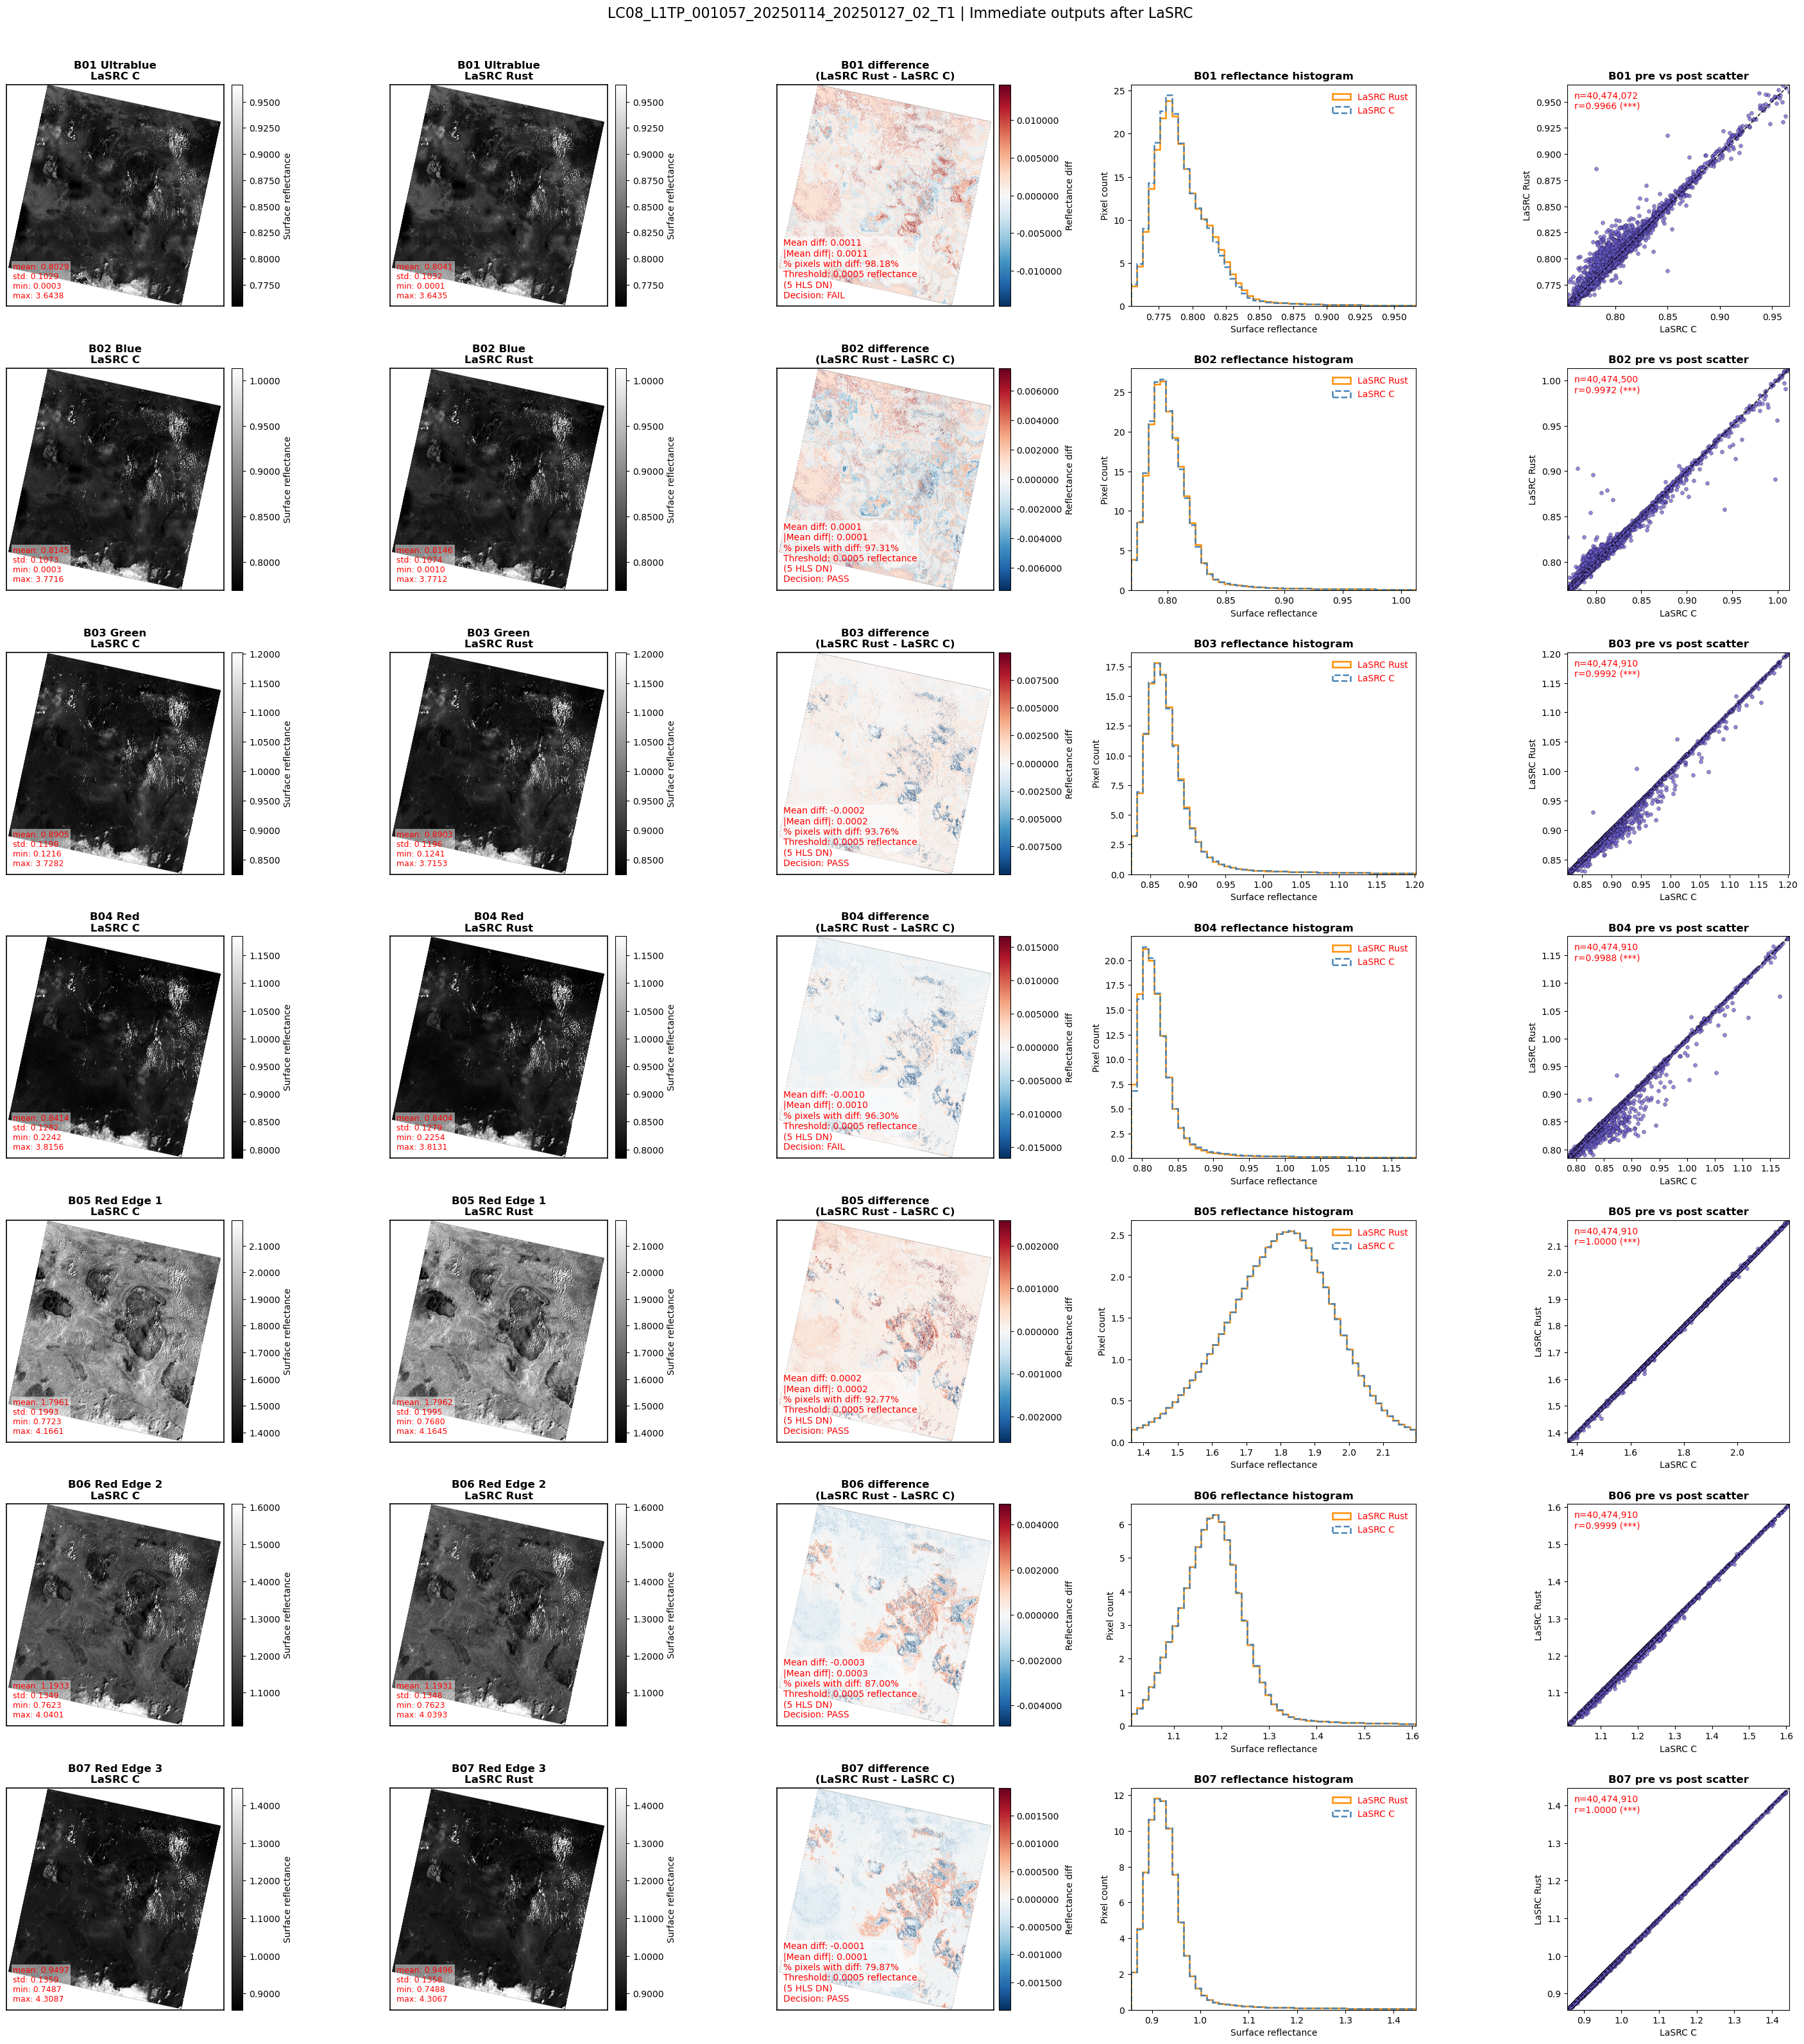

PosixPath('/Users/vo25-mbp/hls-application-lasrc-validation/outputs/lasrc_validation/LC08_L1TP_001057_20250114_20250127_02_T1_immediate_panel.png')

In [28]:
import matplotlib.ticker as mticker


PANEL_TEXT_COLOR = 'red'
PANEL_TEXT_BBOX = dict(
    boxstyle='square,pad=0.20',
    facecolor='white',
    alpha=0.5,
    edgecolor='none',
)


def stage_display_name(stage):
    return {
        'final': 'Final outputs',
        'immediate': 'Immediate outputs after LaSRC',
    }.get(stage, stage)


def panel_threshold_label(value):
    if not np.isfinite(value):
        return 'Threshold: n/a'
    return f'Threshold: {value:.4f} reflectance\n(5 HLS DN)'


def style_image_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor('black')


def significance_label(p_value):
    if not np.isfinite(p_value):
        return 'n/a'
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


def plot_granule_panel(granule_id, stage='final', save=True, show=True):
    subset = df_results[df_results['granule'] == granule_id].copy()
    if stage is not None:
        subset = subset[subset['stage'] == stage].copy()
    if PANEL_BANDS:
        subset = subset[subset['band'].isin(PANEL_BANDS)].copy()

    subset = subset.sort_values(['band_order', 'band'])
    if subset.empty:
        raise RuntimeError(f'No results found for granule={granule_id!r}, stage={stage!r}')

    nrows = len(subset)
    fig, axes = plt.subplots(
        nrows,
        5,
        figsize=(29, max(4.5 * nrows, 6)),
        squeeze=False,
        gridspec_kw={'width_ratios': [1.0, 1.0, 1.0, 1.08, 1.08]},
    )
    fig.suptitle(f'{granule_id} | {stage_display_name(stage)}', fontsize=16, y=1.01)

    for idx, (_, rec) in enumerate(subset.iterrows()):
        pre_refl, post_refl, _, _ = load_pair_reflectance(rec)
        diff = post_refl - pre_refl
        valid = np.isfinite(pre_refl) & np.isfinite(post_refl)
        diff[~valid] = np.nan

        pre_vals = pre_refl[np.isfinite(pre_refl)]
        post_vals = post_refl[np.isfinite(post_refl)]
        pre_common = pre_refl[valid]
        post_common = post_refl[valid]
        diff_vals = diff[np.isfinite(diff)]

        if pre_vals.size and post_vals.size:
            combined = np.concatenate([pre_vals, post_vals])
            vmin, vmax = np.percentile(combined, [2, 98])
            if vmax <= vmin:
                vmax = vmin + 1e-6
        else:
            vmin, vmax = 0.0, 1.0

        if diff_vals.size:
            diff_lim = max(float(np.percentile(np.abs(diff_vals), 98)), 1e-6)
        else:
            diff_lim = 1e-6

        ax_pre, ax_post, ax_diff, ax_hist, ax_scatter = axes[idx]

        im_pre = ax_pre.imshow(np.ma.masked_invalid(pre_refl), cmap='gray', vmin=vmin, vmax=vmax)
        ax_pre.set_title(f'{rec.band} {rec.band_label}\n{PRE_LABEL}', fontweight='bold')
        style_image_axis(ax_pre)
        cbar_pre = fig.colorbar(im_pre, ax=ax_pre, fraction=0.046, pad=0.03)
        cbar_pre.set_label('Surface reflectance')
        cbar_pre.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
        if pre_vals.size:
            pre_stats = (
                f'mean: {np.nanmean(pre_vals):.4f}\n'
                f'std: {np.nanstd(pre_vals):.4f}\n'
                f'min: {np.nanmin(pre_vals):.4f}\n'
                f'max: {np.nanmax(pre_vals):.4f}'
            )
            ax_pre.text(0.03, 0.03, pre_stats, transform=ax_pre.transAxes,
                        fontsize=9, color=PANEL_TEXT_COLOR, va='bottom', ha='left',
                        bbox=PANEL_TEXT_BBOX)

        im_post = ax_post.imshow(np.ma.masked_invalid(post_refl), cmap='gray', vmin=vmin, vmax=vmax)
        ax_post.set_title(f'{rec.band} {rec.band_label}\n{POST_LABEL}', fontweight='bold')
        style_image_axis(ax_post)
        cbar_post = fig.colorbar(im_post, ax=ax_post, fraction=0.046, pad=0.03)
        cbar_post.set_label('Surface reflectance')
        cbar_post.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
        if post_vals.size:
            post_stats = (
                f'mean: {np.nanmean(post_vals):.4f}\n'
                f'std: {np.nanstd(post_vals):.4f}\n'
                f'min: {np.nanmin(post_vals):.4f}\n'
                f'max: {np.nanmax(post_vals):.4f}'
            )
            ax_post.text(0.03, 0.03, post_stats, transform=ax_post.transAxes,
                         fontsize=9, color=PANEL_TEXT_COLOR, va='bottom', ha='left',
                         bbox=PANEL_TEXT_BBOX)

        norm = mcolors.TwoSlopeNorm(vmin=-diff_lim, vcenter=0.0, vmax=diff_lim)
        im = ax_diff.imshow(np.ma.masked_invalid(diff), cmap='RdBu_r', norm=norm)
        ax_diff.set_title(f'{rec.band} difference\n({POST_LABEL} - {PRE_LABEL})', fontweight='bold')
        style_image_axis(ax_diff)
        stats_text = (
            f'Mean diff: {rec.mean_diff_refl:.4f}\n'
            f'|Mean diff|: {rec.abs_mean_diff_refl:.4f}\n'
            f'% pixels with diff: {rec.pct_pixels_changed:.2f}%\n'
            f'{panel_threshold_label(rec.threshold_refl)}\n'
            f'Decision: {rec.decision}'
        )
        ax_diff.text(0.03, 0.03, stats_text, transform=ax_diff.transAxes,
                     fontsize=10, color=PANEL_TEXT_COLOR, va='bottom', ha='left',
                     bbox=PANEL_TEXT_BBOX)
        cbar_diff = fig.colorbar(im, ax=ax_diff, fraction=0.046, pad=0.02)
        cbar_diff.set_label('Reflectance diff')
        cbar_diff.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.6f'))

        hist_bins = np.linspace(vmin, vmax, 50) if np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin else 18
        if post_vals.size:
            ax_hist.hist(post_vals, bins=hist_bins, histtype='step', linewidth=1.8, color='darkorange', label=POST_LABEL, alpha=0.98, density=True)
        if pre_vals.size:
            ax_hist.hist(pre_vals, bins=hist_bins, histtype='step', linewidth=1.8, linestyle='--', color='steelblue', label=PRE_LABEL, alpha=0.98, density=True)
        ax_hist.set_title(f'{rec.band} reflectance histogram', fontweight='bold')
        ax_hist.set_xlabel('Surface reflectance')
        ax_hist.set_ylabel('Pixel count')
        ax_hist.set_xlim(vmin, vmax)
        ax_hist.grid(False)
        hist_legend = ax_hist.legend(frameon=True, facecolor='white', edgecolor='none',
                                     framealpha=0.5, fancybox=False)
        if hist_legend is not None:
            for text in hist_legend.get_texts():
                text.set_color(PANEL_TEXT_COLOR)

        if pre_common.size and post_common.size:
            scatter_n = min(10000, pre_common.size)
            rng = np.random.default_rng(0)
            scatter_idx = rng.choice(pre_common.size, size=scatter_n, replace=False)
            x = pre_common[scatter_idx]
            y = post_common[scatter_idx]
            xy_all = np.concatenate([pre_common, post_common])
            smin = float(np.nanpercentile(xy_all, 2))
            smax = float(np.nanpercentile(xy_all, 98))
            if smax <= smin:
                smax = smin + 1e-6
            ax_scatter.scatter(x, y, s=18, alpha=0.72, color='slateblue', marker='o', edgecolors='black', linewidth=0.3)
            ax_scatter.plot([smin, smax], [smin, smax], linestyle='--', color='black', linewidth=1)
            ax_scatter.set_xlim(smin, smax)
            ax_scatter.set_ylim(smin, smax)
            ax_scatter.set_aspect('equal', adjustable='box')
            corr = float(np.corrcoef(pre_common, post_common)[0, 1]) if pre_common.size >= 2 else np.nan
            p_value = np.nan
            if scatter_n >= 3:
                try:
                    from scipy.stats import pearsonr
                    corr_stat = pearsonr(x, y)
                    corr = float(corr_stat.statistic)
                    p_value = float(corr_stat.pvalue)
                except Exception:
                    p_value = np.nan
            sig = significance_label(p_value)
            ax_scatter.text(0.03, 0.97,
                            f'n={pre_common.size:,}\nr={corr:.4f} ({sig})',
                            transform=ax_scatter.transAxes, va='top', ha='left',
                            fontsize=10, color=PANEL_TEXT_COLOR, bbox=PANEL_TEXT_BBOX)
        ax_scatter.set_title(f'{rec.band} pre vs post scatter', fontweight='bold')
        ax_scatter.set_xlabel(PRE_LABEL)
        ax_scatter.set_ylabel(POST_LABEL)
        ax_scatter.grid(False)

    plt.tight_layout()
    fig.subplots_adjust(wspace=0.44, hspace=0.28)

    panel_path = None
    if save:
        panel_path = OUTPUTS_DIR / f'{sanitize_name(granule_id)}_{stage}_panel.png'
        fig.savefig(panel_path, dpi=150, bbox_inches='tight')
        print(f'Saved panel image: {panel_path}')

    if show:
        plt.show()
    else:
        plt.close(fig)

    return panel_path


def plot_all_granule_panels(stage='auto', save=True, show=False, granules=None, max_granules=None):
    if granules is None:
        granule_ids = sorted(df_results['granule'].dropna().unique())
    else:
        granule_ids = [g for g in granules if g in set(df_results['granule'])]

    if max_granules is not None:
        granule_ids = granule_ids[:max_granules]

    saved_rows = []
    failed_rows = []

    for idx, granule_id in enumerate(granule_ids, start=1):
        available_stages = sorted(df_results[df_results['granule'] == granule_id]['stage'].dropna().unique())
        if not available_stages:
            failed_rows.append({'granule': granule_id, 'stage': None, 'error': 'No stages available'})
            continue

        selected_stage = stage
        if stage == 'auto':
            selected_stage = 'final' if 'final' in available_stages else available_stages[0]

        print(f'[{idx:03d}/{len(granule_ids):03d}] Plotting {granule_id} | {stage_display_name(selected_stage)}')

        try:
            panel_path = plot_granule_panel(
                granule_id=granule_id,
                stage=selected_stage,
                save=save,
                show=show,
            )
            saved_rows.append({
                'granule': granule_id,
                'stage': selected_stage,
                'panel_path': str(panel_path) if panel_path is not None else None,
            })
        except Exception as exc:
            failed_rows.append({
                'granule': granule_id,
                'stage': selected_stage,
                'error': str(exc),
            })
            print(f'⚠️  Failed to plot {granule_id} | {selected_stage}: {exc}')

    df_saved = pd.DataFrame(saved_rows)
    df_failed = pd.DataFrame(failed_rows)

    if not df_saved.empty:
        display(df_saved.head(20))
    if not df_failed.empty:
        print('\nSome granules failed during panel generation:')
        display(df_failed.head(20))

    return df_saved, df_failed


panel_stage = PANEL_STAGE
available_panel_granules = sorted(df_results['granule'].dropna().unique())
if not available_panel_granules:
    raise RuntimeError('df_results is empty after filtering, so no granule panels can be plotted.')
if PANEL_GRANULE not in set(available_panel_granules):
    PANEL_GRANULE = available_panel_granules[0]
    print(f'Using PANEL_GRANULE = {PANEL_GRANULE}')

available_stages = sorted(df_results[df_results['granule'] == PANEL_GRANULE]['stage'].dropna().unique())
if not available_stages:
    raise RuntimeError(f'No stages are available for PANEL_GRANULE={PANEL_GRANULE!r} after filtering.')
if panel_stage == 'auto':
    panel_stage = 'final' if 'final' in available_stages else available_stages[0]

panel_path = plot_granule_panel(
    granule_id=PANEL_GRANULE,
    stage=panel_stage,
    save=SAVE_PANEL_IMAGES,
    show=SHOW_INLINE_PANELS,
)
panel_path

# To generate panels for every granule, run for example:
# all_panels, panel_failures = plot_all_granule_panels(stage='auto', save=True, show=False)
# all_panels


---
## 8. Overall Summary Across Granules

This section summarizes the comparison across all granules using **mean surface reflectance per granule-band pair** and shows the relationship between the pre and post container outputs.

It also includes a band-level summary panel showing the **mean absolute difference across all granules** together with the threshold reference for each band.


,stage,band,band_label,granules,compared_pairs,threshold_source,threshold_refl,strict_threshold_refl,relaxed_threshold_refl,reference_threshold_refl,mean_pre_refl,mean_post_refl,mean_mean_diff_refl,mean_abs_mean_diff_refl,max_abs_mean_diff_refl,pass_rate_pct
0,immediate,B01,Ultrablue,10,10,5 HLS DN equivalence threshold,0.0005,0.0005,0.0005,0.0005,1.130167,1.130198,0.000041,0.000656,0.002353,60.0
1,immediate,B02,Blue,10,10,5 HLS DN equivalence threshold,0.0005,0.0005,0.0005,0.0005,1.137600,1.137477,-0.000123,0.000421,0.002109,70.0
2,immediate,B03,Green,10,10,5 HLS DN equivalence threshold,0.0005,0.0005,0.0005,0.0005,1.181908,1.181779,-0.000132,0.000305,0.001518,80.0
3,immediate,B04,Red,10,10,5 HLS DN equivalence threshold,0.0005,0.0005,0.0005,0.0005,1.156698,1.156476,-0.000238,0.000334,0.001269,70.0
4,immediate,B05,Red Edge 1,10,10,5 HLS DN equivalence threshold,0.0005,0.0005,0.0005,0.0005,1.829805,1.829696,-0.000110,0.000171,0.000874,90.0
5,immediate,B06,Red Edge 2,10,10,5 HLS DN equivalence threshold,0.0005,0.0005,0.0005,0.0005,1.216546,1.216453,-0.000093,0.000123,0.000513,90.0
6,immediate,B07,Red Edge 3,10,10,5 HLS DN equivalence threshold,0.0005,0.0005,0.0005,0.0005,1.028804,1.028767,-0.000037,0.000052,0.000268,100.0


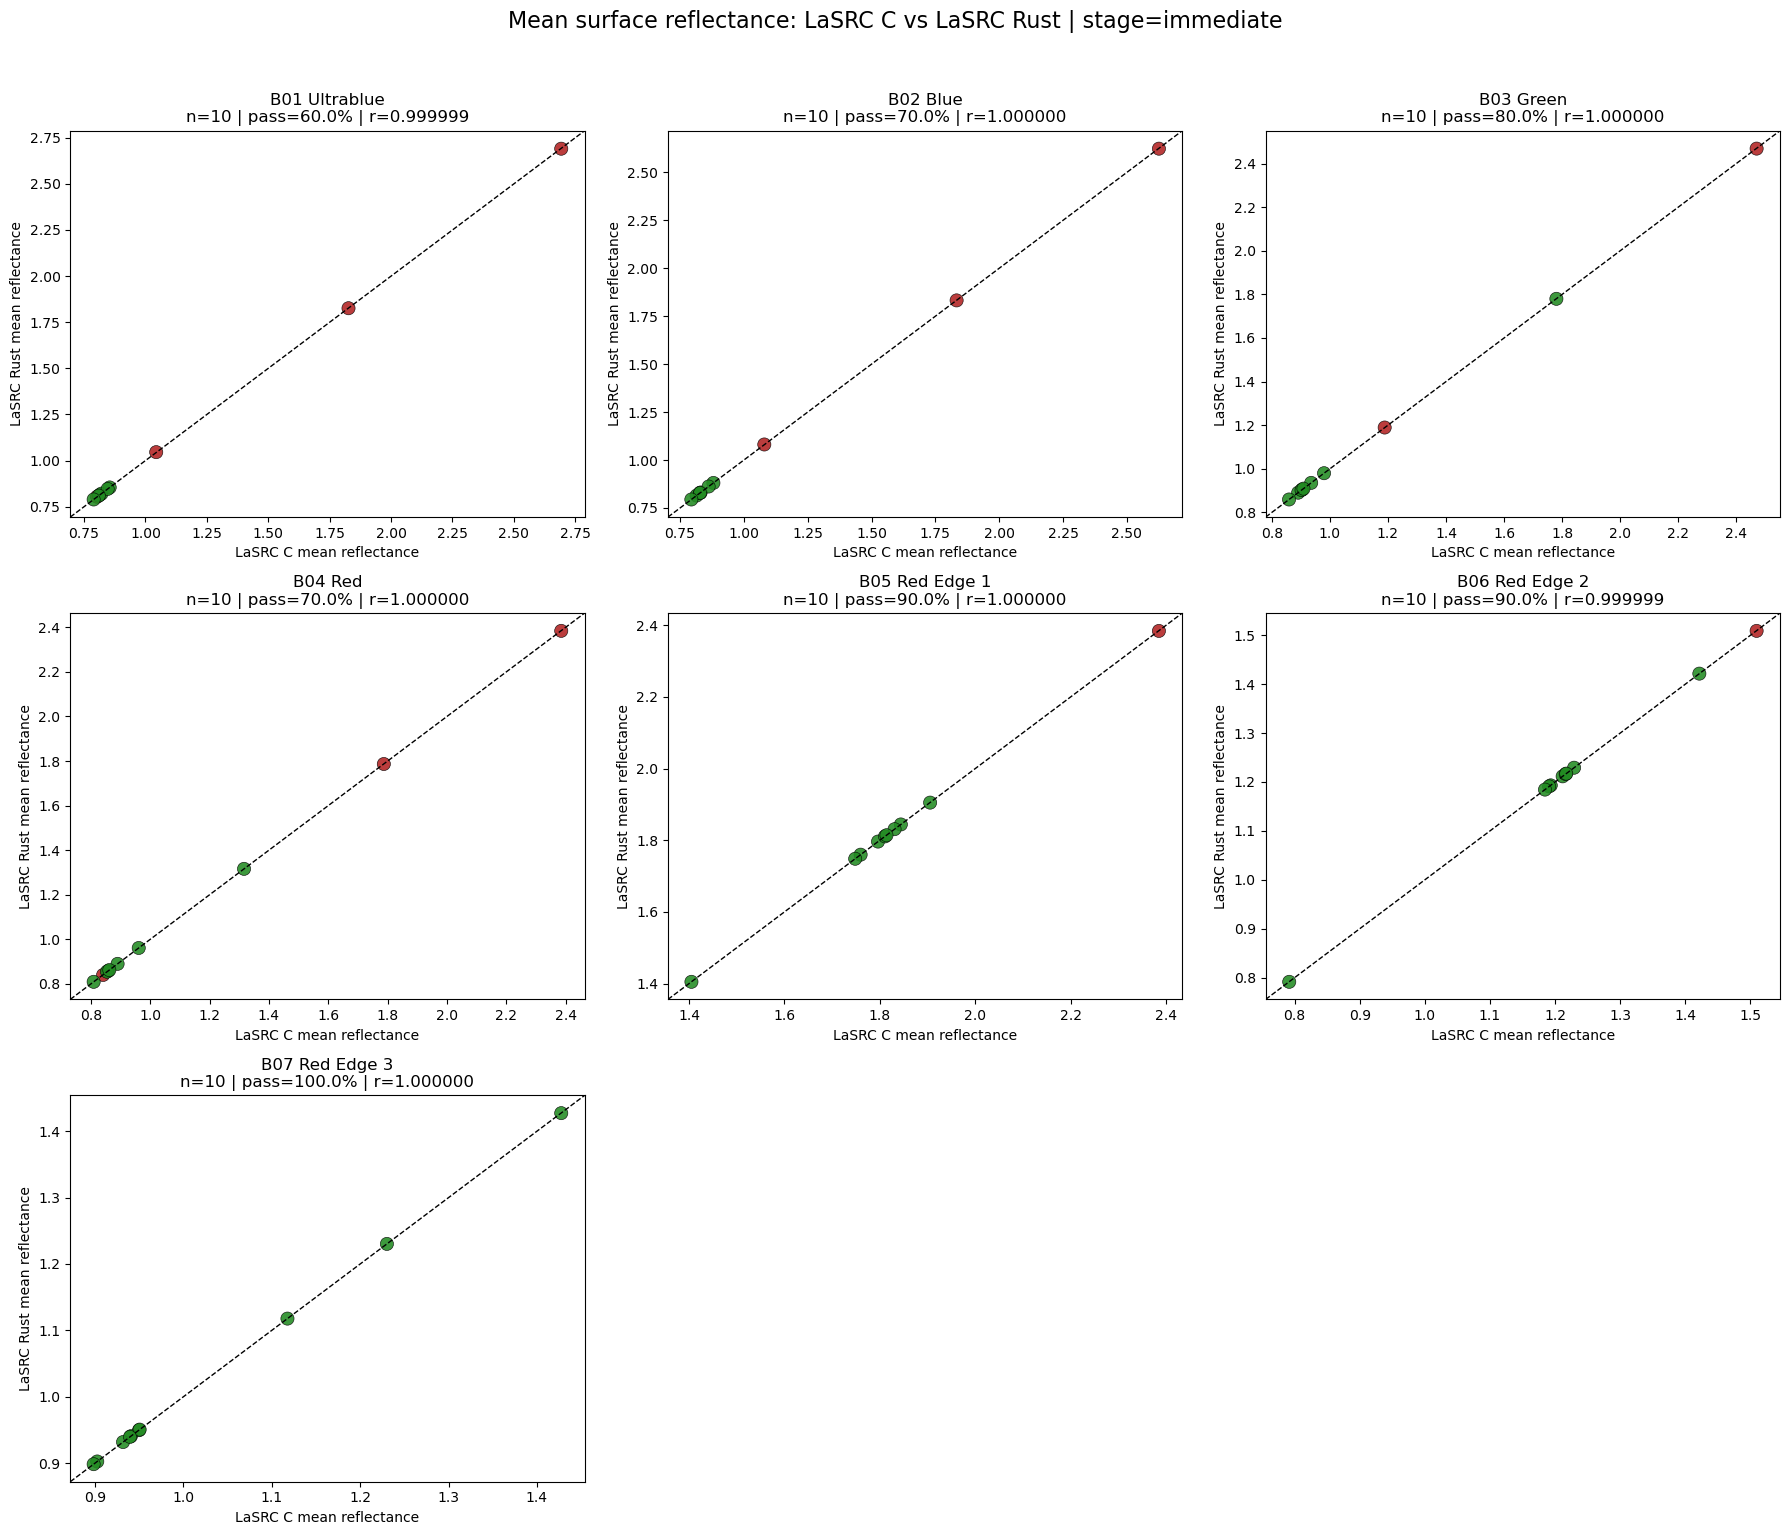

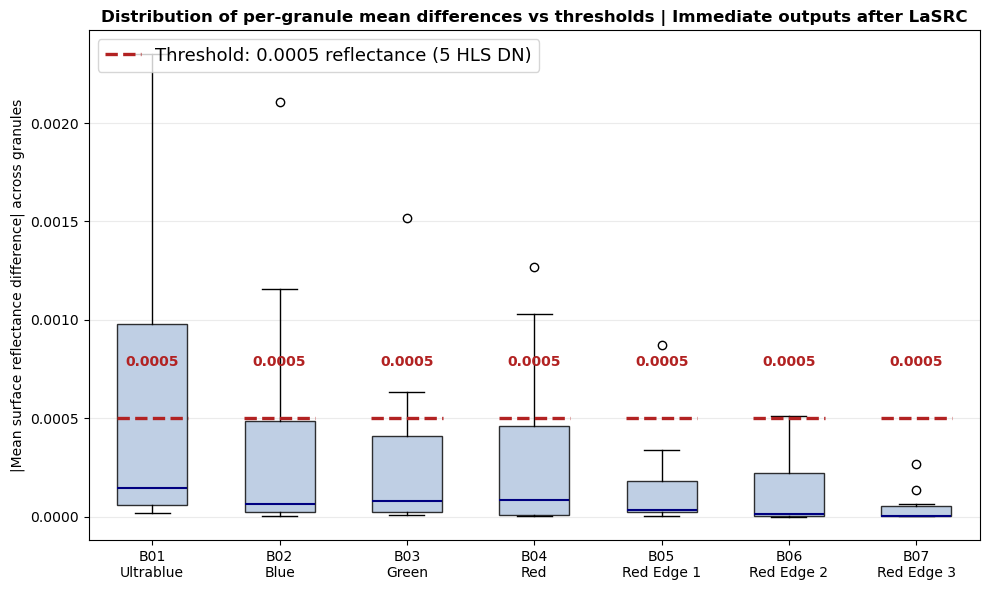

In [13]:
def stage_display_name(stage):
    return {
        'final': 'Final outputs',
        'immediate': 'Immediate outputs after LaSRC',
    }.get(stage, stage)


# Reuse existing Section 6 results without re-reading rasters. This makes an
# updated threshold take effect immediately in the scatter and boxplot summaries.
df_results = df_results.copy()
df_results['threshold_source'] = THRESHOLD_SOURCE
df_results['threshold_refl'] = THRESHOLD_REFL
df_results['strict_threshold_refl'] = THRESHOLD_REFL
df_results['relaxed_threshold_refl'] = THRESHOLD_REFL
df_results['reference_threshold_refl'] = THRESHOLD_REFL
df_results['decision'] = np.where(
    df_results['abs_mean_diff_refl'].le(THRESHOLD_REFL), 'PASS', 'FAIL'
)
df_results.loc[df_results['abs_mean_diff_refl'].isna(), 'decision'] = 'NO_VALID_PIXELS'
df_results['pass_score'] = np.where(
    df_results['abs_mean_diff_refl'].notna(),
    (df_results['abs_mean_diff_refl'] <= THRESHOLD_REFL).astype(float),
    np.nan,
)

required_threshold_cols = [
    'threshold_source',
    'threshold_refl',
    'strict_threshold_refl',
    'relaxed_threshold_refl',
    'reference_threshold_refl',
]

required_storage_cols = [
    'pre_storage_type',
    'pre_storage_root',
    'post_storage_type',
    'post_storage_root',
    'pre_key',
    'post_key',
]
required_backfill_cols = required_threshold_cols + required_storage_cols
missing_backfill_cols = [c for c in required_backfill_cols if c not in df_results.columns]
if missing_backfill_cols:
    if 'pair_id' not in df_results.columns:
        raise KeyError(
            'df_results is missing backfill columns and cannot be repaired because pair_id is unavailable. '
            'Rerun the comparison cell to rebuild df_results.'
        )
    backfill_cols = ['pair_id'] + [c for c in required_backfill_cols if c in paired_catalog.columns]
    lookup = paired_catalog[backfill_cols].drop_duplicates(subset=['pair_id'])
    df_results = df_results.merge(lookup, on='pair_id', how='left', suffixes=('', '_ref'))
    for col in required_backfill_cols:
        ref_col = f'{col}_ref'
        if col not in df_results.columns and ref_col in df_results.columns:
            df_results[col] = df_results[ref_col]
        elif ref_col in df_results.columns:
            df_results[col] = df_results[col].where(df_results[col].notna(), df_results[ref_col])
    df_results = df_results.drop(columns=[c for c in df_results.columns if c.endswith('_ref')])

overall_summary = (
    df_results.groupby(['stage', 'band', 'band_label'], dropna=False)
    .agg(
        granules=('granule', 'nunique'),
        compared_pairs=('pair_id', 'size'),
        threshold_source=('threshold_source', 'first'),
        threshold_refl=('threshold_refl', 'first'),
        strict_threshold_refl=('strict_threshold_refl', 'first'),
        relaxed_threshold_refl=('relaxed_threshold_refl', 'first'),
        reference_threshold_refl=('reference_threshold_refl', 'first'),
        mean_pre_refl=('mean_pre_refl', 'mean'),
        mean_post_refl=('mean_post_refl', 'mean'),
        mean_mean_diff_refl=('mean_diff_refl', 'mean'),
        mean_abs_mean_diff_refl=('abs_mean_diff_refl', 'mean'),
        max_abs_mean_diff_refl=('abs_mean_diff_refl', 'max'),
        pass_rate_pct=('pass_score', lambda s: float(np.nanmean(s) * 100.0) if np.isfinite(s).any() else np.nan),
    )
    .reset_index()
)
overall_summary['band_order'] = overall_summary['band'].apply(band_sort_key)
overall_summary = overall_summary.sort_values(['stage', 'band_order', 'band']).drop(columns='band_order')

display(overall_summary)

stages_to_plot = sorted(df_results['stage'].dropna().unique())
# Summary plots include every discovered band. PANEL_BANDS applies only to
# the optional per-granule visualization above.
plot_band_order = []
for stage_name in stages_to_plot:
    stage_df = df_results[df_results['stage'] == stage_name].copy()
    if plot_band_order:
        bands = [band for band in plot_band_order if band in set(stage_df['band'].dropna())]
    else:
        bands = sorted(stage_df['band'].dropna().unique(), key=band_sort_key)
    if not bands:
        continue

    ncols = 3
    nrows = math.ceil(len(bands) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
    fig.suptitle(f'Mean surface reflectance: {PRE_LABEL} vs {POST_LABEL} | stage={stage_name}', fontsize=16, y=1.02)

    for ax in axes.ravel():
        ax.axis('off')

    for ax, band in zip(axes.ravel(), bands):
        ax.axis('on')
        sub = stage_df[stage_df['band'] == band].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        # Use the full stored mean reflectance values (float64), not rounded display values.
        x = sub['mean_pre_refl'].to_numpy(dtype=np.float64)
        y = sub['mean_post_refl'].to_numpy(dtype=np.float64)
        colors = np.where(sub['decision'].to_numpy() == 'PASS', 'forestgreen', 'firebrick')
        ax.scatter(x, y, c=colors, s=90, alpha=0.88, edgecolor='black', linewidth=0.45)

        finite = np.isfinite(x) & np.isfinite(y)
        corr = np.nan
        if finite.any():
            xy = np.concatenate([x[finite], y[finite]])
            lo = float(np.nanmin(xy))
            hi = float(np.nanmax(xy))
            if hi <= lo:
                hi = lo + 1e-6
            pad = (hi - lo) * 0.05
            ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', color='black', linewidth=1)
            ax.set_xlim(lo - pad, hi + pad)
            ax.set_ylim(lo - pad, hi + pad)
            if finite.sum() >= 2:
                corr = float(np.corrcoef(x[finite], y[finite])[0, 1])

        pass_rate = float(np.nanmean(sub['pass_score']) * 100.0) if np.isfinite(sub['pass_score']).any() else np.nan
        title = f'{band} {sub["band_label"].iloc[0]}\n' f'n={len(sub)} | pass={pass_rate:.1f}%'
        if np.isfinite(corr):
            title += f' | r={corr:.6f}'
        ax.set_title(title)
        ax.set_xlabel(f'{PRE_LABEL} mean reflectance')
        ax.set_ylabel(f'{POST_LABEL} mean reflectance')
        ax.grid(False)

    plt.tight_layout()
    plt.show()

for stage_name in stages_to_plot:
    stage_df = df_results[df_results['stage'] == stage_name].copy()
    stage_summary = overall_summary[overall_summary['stage'] == stage_name].copy()
    if stage_df.empty or stage_summary.empty:
        continue

    if plot_band_order:
        stage_df = stage_df[stage_df['band'].isin(plot_band_order)].copy()
        stage_summary = stage_summary[stage_summary['band'].isin(plot_band_order)].copy()
    stage_summary['band_order'] = stage_summary['band'].apply(band_sort_key)
    stage_summary = stage_summary.sort_values(['band_order', 'band'])
    bands = stage_summary['band'].tolist()
    box_data = []
    for band in bands:
        vals = stage_df.loc[stage_df['band'] == band, 'abs_mean_diff_refl'].dropna().to_numpy(dtype=float)
        box_data.append(vals)

    fig, ax = plt.subplots(figsize=(max(10, 1.35 * len(bands)), 6))
    bp = ax.boxplot(box_data, patch_artist=True, widths=0.55, showfliers=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')
        patch.set_alpha(0.8)
    for median in bp['medians']:
        median.set_color('navy')
        median.set_linewidth(1.5)

    x = np.arange(1, len(bands) + 1)
    threshold_vals = stage_summary['threshold_refl'].to_numpy(dtype=float)
    finite_box_vals = np.concatenate([vals for vals in box_data if vals.size]) if any(vals.size for vals in box_data) else np.array([], dtype=float)
    if finite_box_vals.size:
        y_span = float(np.nanmax(finite_box_vals) - np.nanmin(finite_box_vals))
    else:
        y_span = 0.0
    text_offset = max(y_span * 0.035, 0.00025)

    for xi, threshold_val in zip(x, threshold_vals):
        if np.isfinite(threshold_val):
            ax.hlines(threshold_val, xi - 0.28, xi + 0.28, colors='firebrick', linestyles='--', linewidth=2.4)
            ax.text(
                xi,
                threshold_val + text_offset,
                f'{threshold_val:.4f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='firebrick',
                fontweight='bold',
            )

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color='firebrick', linestyle='--', linewidth=2.4, label='Threshold: 0.0005 reflectance (5 HLS DN)'),
    ]

    ax.set_xticks(x)
    ax.set_xticklabels([f'{band}\n{label}' for band, label in zip(stage_summary['band'], stage_summary['band_label'])])
    ax.set_ylabel('|Mean surface reflectance difference| across granules')
    ax.set_title(f'Distribution of per-granule mean differences vs thresholds | {stage_display_name(stage_name)}', fontweight='bold')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(handles=legend_handles, loc='upper left', fontsize=13)
    plt.tight_layout()
    plt.show()
